# Notebook 03 — Modelos Baseline y ARIMA

Este notebook implementa los modelos de referencia (baseline) y el modelo
ARIMA para la predicción de la huella de carbono operacional del sistema
eléctrico español con resolución de 15 minutos.

**Punto de partida:** el modelo más simple posible — copiar el valor
de la misma hora del día anterior. A partir de ahí se introduce ARIMA
para intentar mejorar esa referencia.

**Horizontes de predicción:** 48h (192 pasos) y 72h (288 pasos).

**Evaluación:** walk-forward con 45 evaluaciones distribuidas por 2024
con paso de 8 días (no múltiplo de 7 para evitar sesgo por día de la semana).
Primer fit ~8 enero, último ~24 diciembre. Se reportan media, desviación
estándar e intervalo de confianza al 95% mediante bootstrap (1000 iteraciones).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

plt.style.use("seaborn-v0_8")
%matplotlib inline

BASE_DIR    = Path("/home/ubuntu/TFM/notebooks")
DATA_DIR    = BASE_DIR / "data_processed"
RESULTS_DIR = Path("/home/ubuntu/TFM/results")
RESULTS_DIR.mkdir(exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)

DATA_DIR: /home/ubuntu/TFM/notebooks/data_processed
RESULTS_DIR: /home/ubuntu/TFM/results


## 1. Carga de datos

Se cargan los parquets generados en el notebook 01, manteniendo
la misma división temporal que el resto de modelos:
- Train: 2022–2023
- Validación: 2024
- Test: 2025

In [75]:
y_train = pd.read_parquet(DATA_DIR / "train_2022_2023.parquet")["y"].astype(float)
y_val   = pd.read_parquet(DATA_DIR / "val_2024.parquet")["y"].astype(float)
y_test  = pd.read_parquet(DATA_DIR / "test_2025.parquet")["y"].astype(float)

y_train.index = pd.to_datetime(y_train.index)
y_val.index   = pd.to_datetime(y_val.index)
y_test.index  = pd.to_datetime(y_test.index)

print("Train:", y_train.shape, "|", y_train.index.min(), "->", y_train.index.max())
print("Val:  ", y_val.shape,   "|", y_val.index.min(),   "->", y_val.index.max())
print("Test: ", y_test.shape,  "|", y_test.index.min(),  "->", y_test.index.max())

Train: (70080,) | 2022-01-01 00:00:00+00:00 -> 2023-12-31 23:45:00+00:00
Val:   (35136,) | 2024-01-01 00:00:00+00:00 -> 2024-12-31 23:45:00+00:00
Test:  (35040,) | 2025-01-01 00:00:00+00:00 -> 2025-12-31 23:45:00+00:00


## 2. Configuración temporal y métricas

La serie tiene resolución de 15 minutos, por lo que:
- 1 hora = 4 pasos
- 24 horas = 96 pasos (periodo estacional diario)
- 48 horas = 192 pasos
- 72 horas = 288 pasos

In [76]:
FREQ_MIN        = 15
STEPS_PER_HOUR  = 60 // FREQ_MIN
SEASONAL_PERIOD = 24 * STEPS_PER_HOUR  # 96

HORIZONS = {
    "48h": 48 * STEPS_PER_HOUR,  # 192 pasos
    "72h": 72 * STEPS_PER_HOUR,  # 288 pasos
}

@dataclass
class WFConfig:
    step: int
    min_history: int
    max_fits: int

def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"MAE": mae, "RMSE": rmse}

print("Periodo estacional:", SEASONAL_PERIOD)
print("Horizontes:", HORIZONS)

Periodo estacional: 96
Horizontes: {'48h': 192, '72h': 288}


In [77]:

# Configuración walk-forward — paso de 8 días (no múltiplo de 7)
# para evitar sesgo por día de la semana. Válido para todos los modelos.
cfg_wf = WFConfig(
    step=8 * SEASONAL_PERIOD,
    min_history=7 * SEASONAL_PERIOD,
    max_fits=45
)

# Indices distribuidos a lo largo del año
PLOT_INDICES = [2, 15, 30, 42]

def walk_forward_splits(series, horizons, cfg):
    n     = len(series)
    max_h = max(horizons.values())
    points = list(range(cfg.min_history, n - max_h, cfg.step))
    points = points[:cfg.max_fits]
    for t0 in points:
        train_part = series.iloc[:t0]
        tests = {k: series.iloc[t0:t0 + h] for k, h in horizons.items()}
        yield train_part, tests

def summarize(df, model_name):
    out = (
        df.groupby("horizon")[["MAE", "RMSE"]]
        .mean()
        .reset_index()
    )
    out.insert(0, "model", model_name)
    return out

def evaluate_model(y_train, y_val, horizons, cfg, forecaster, verbose=False):
    rows        = []
    preds_store = []
    y_full  = pd.concat([y_train, y_val]).sort_index()
    n_train = len(y_train)
    splits  = list(walk_forward_splits(y_val, horizons, cfg))
    total   = len(splits)

    for i, (train_part, tests) in enumerate(splits, 1):
        if verbose:
            print(f"Fit {i}/{total}")
        cutoff_idx   = n_train + len(train_part)
        cutoff_time  = y_full.index[cutoff_idx - 1]
        train_window = y_full.iloc[:cutoff_idx]

        fit_preds = {"cutoff_time": cutoff_time, "train_window": train_window}
        for name, test in tests.items():
            pred = forecaster(train_window, len(test))
            m    = compute_metrics(test.values, pred)
            rows.append({"horizon": name, "MAE": m["MAE"], "RMSE": m["RMSE"]})
            fit_preds[name] = {"pred": pred, "test": test}
        preds_store.append(fit_preds)

    return pd.DataFrame(rows), preds_store

# --- Bootstrap para intervalos de confianza ---

def bootstrap_ci(errors, n_boot=1000, ci=95):
    rng = np.random.default_rng(42)
    boot_means = np.array([
        rng.choice(errors, size=len(errors), replace=True).mean()
        for _ in range(n_boot)
    ])
    lower = np.percentile(boot_means, (100 - ci) / 2)
    upper = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return lower, upper

def summarize_with_ci(df, model_name):
    rows = []
    for horizon, group in df.groupby("horizon"):
        mae_vals = group["MAE"].values
        rmse_vals = group["RMSE"].values
        mae_lo, mae_hi = bootstrap_ci(mae_vals)
        rmse_lo, rmse_hi = bootstrap_ci(rmse_vals)
        rows.append({
            "model": model_name,
            "horizon": horizon,
            "MAE_mean": mae_vals.mean(),
            "MAE_std": mae_vals.std(),
            "MAE_ci_lo": mae_lo,
            "MAE_ci_hi": mae_hi,
            "RMSE_mean": rmse_vals.mean(),
            "RMSE_std": rmse_vals.std(),
            "RMSE_ci_lo": rmse_lo,
            "RMSE_ci_hi": rmse_hi,
            "n_eval": len(mae_vals)
        })
    return pd.DataFrame(rows)

print("cfg_wf: step=28 días, max_fits=12")
print("cfg_plot: step=1 día, max_fits=300 (solo para gráficas)")
print(f"PLOT_INDICES: {PLOT_INDICES}")

cfg_wf: step=28 días, max_fits=12
cfg_plot: step=1 día, max_fits=300 (solo para gráficas)
PLOT_INDICES: [2, 15, 30, 42]


## 4. Modelos Baseline (Naive)

Los modelos naive sirven como referencia mínima — cualquier modelo
más complejo debe superarlos para justificar su uso.

**Naive_last:** predice el último valor observado para todo el horizonte.

**Naive_seasonal:** retrocede exactamente H pasos atrás y copia ese
segmento como predicción:
- Para 48h -> copia los 2 días anteriores
- Para 72h -> copia los 3 días anteriores

In [78]:
def forecast_naive_last(train, h):
    return np.repeat(train.values[-1], h)

def forecast_naive_seasonal(train, h, season=96):
    if len(train) < season:
        return forecast_naive_last(train, h)
    pattern = train.values[-season:]
    reps = int(np.ceil(h / season))
    return np.tile(pattern, reps)[:h]

print("Naive_last: predice el último valor observado")
print("Naive_seasonal: copia el patrón de hace H pasos")

Naive_last: predice el último valor observado
Naive_seasonal: copia el patrón de hace H pasos


## 5. Evaluación Naive

In [79]:
print("Evaluando Naive_last...")
naive_last_val, _ = evaluate_model(
    y_train, y_val, HORIZONS, cfg_wf,
    forecast_naive_last
)

print("Evaluando Naive_seasonal...")
naive_seas_val, preds_naive = evaluate_model(
    y_train, y_val, HORIZONS, cfg_wf,
    lambda tr, h: forecast_naive_seasonal(tr, h)
)

# Resumen simple
naive_summary = pd.concat([
    summarize(naive_last_val, "Naive_last"),
    summarize(naive_seas_val, "Naive_seasonal")
])

# Resumen con intervalos de confianza
naive_last_ci = summarize_with_ci(naive_last_val, "Naive_last")
naive_seas_ci = summarize_with_ci(naive_seas_val, "Naive_seasonal")
naive_ci = pd.concat([naive_last_ci, naive_seas_ci], ignore_index=True)

print("\n=== Resultados con IC 95% ===")
for _, r in naive_ci.iterrows():
    print(f"{r['model']:20s} {r['horizon']:4s}  "
          f"MAE = {r['MAE_mean']:.2f} ± {r['MAE_std']:.2f}  "
          f"[{r['MAE_ci_lo']:.2f}, {r['MAE_ci_hi']:.2f}]  "
          f"(n={int(r['n_eval'])})")


Evaluando Naive_last...
Evaluando Naive_seasonal...

=== Resultados con IC 95% ===
Naive_last           48h   MAE = 28.13 ± 12.37  [24.68, 32.03]  (n=45)
Naive_last           72h   MAE = 30.92 ± 14.96  [26.60, 35.65]  (n=45)
Naive_seasonal       48h   MAE = 21.00 ± 14.93  [16.95, 25.91]  (n=45)
Naive_seasonal       72h   MAE = 23.11 ± 17.00  [18.43, 28.63]  (n=45)


## 6. Visualización Naive_seasonal

El Naive_seasonal es el baseline principal — cualquier modelo
más complejo debe superar este resultado para justificar su uso.
Se muestran 4 puntos representativos distribuidos por 2024.

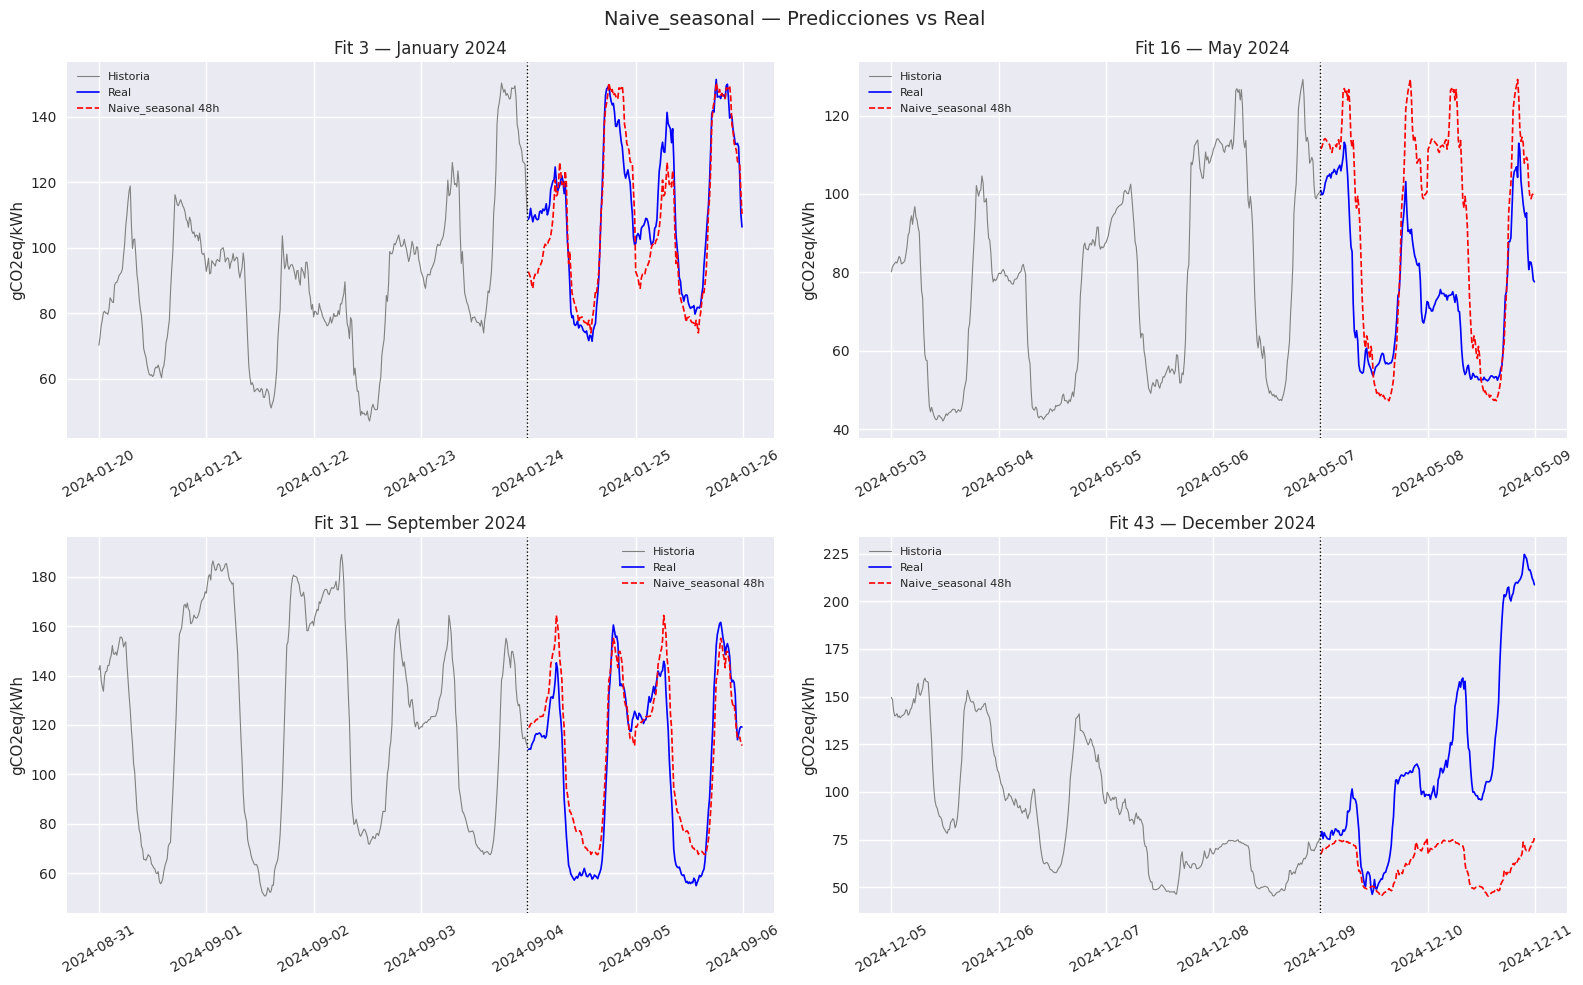

In [81]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Naive_seasonal — Predicciones vs Real", fontsize=14)

for idx, split_idx in enumerate(PLOT_INDICES):
    ax = axes[idx // 2][idx % 2]
    fit         = preds_naive[split_idx]
    cutoff_time = fit["cutoff_time"]
    train_w     = fit["train_window"]
    test_48     = fit["48h"]["test"]
    pred_48     = fit["48h"]["pred"]

    history = train_w.iloc[-4 * SEASONAL_PERIOD:]
    ax.plot(history.index, history.values,
            color="gray", label="Historia", linewidth=0.8)
    ax.plot(test_48.index, test_48.values,
            color="blue", label="Real", linewidth=1.2)
    ax.plot(test_48.index, pred_48,
            color="red", linestyle="--", label="Naive_seasonal 48h", linewidth=1.2)
    ax.axvline(x=cutoff_time, color="black", linestyle=":", linewidth=1.0)
    ax.set_title(f"Fit {split_idx+1} — {cutoff_time.strftime('%B %Y')}")
    ax.set_ylabel("gCO2eq/kWh")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("/home/ubuntu/TFM/figures/naive_predicciones.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Selección del orden ARIMA — Metodología Box-Jenkins

La metodología Box-Jenkins define un proceso sistemático para
identificar, estimar y validar modelos ARIMA:

1. **Identificación**: análisis de ACF y PACF para determinar p, d, q
   - PACF corta en lag p -> componente AR(p)
   - ACF corta en lag q -> componente MA(q)
   - Número de diferenciaciones necesarias para estacionariedad -> d

2. **Estimación**: ajuste del modelo por máxima verosimilitud

3. **Validación**: análisis de residuos — deben comportarse como ruido blanco

En este notebook se automatiza la fase de identificación con
auto_arima, que implementa la búsqueda stepwise minimizando el AIC.
Esto es equivalente al proceso manual Box-Jenkins pero de forma
sistemática y reproducible.

In [82]:
from pmdarima import auto_arima

# Usar últimos 90 días de train para seleccionar orden
sample = y_train.iloc[-90 * SEASONAL_PERIOD:]

print(f"Muestra para auto_arima: {len(sample)} observaciones ({len(sample)//96} días)")
print("Buscando orden óptimo con auto_arima...")
auto_model = auto_arima(
    sample.values,
    start_p=0, max_p=6,
    start_q=0, max_q=3,
    d=None,              # auto-detectar diferenciación
    seasonal=False,      # sin componente estacional 
    information_criterion="aic",
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    verbose=False
)

arima_order = auto_model.order
print("Orden óptimo encontrado:", arima_order)
print("AIC:", round(auto_model.aic(), 2))
print(auto_model.summary())


Muestra para auto_arima: 8640 observaciones (90 días)
Buscando orden óptimo con auto_arima...


Orden óptimo encontrado: (6, 1, 1)
AIC: 40418.72
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 8640
Model:               SARIMAX(6, 1, 1)   Log Likelihood              -20201.362
Date:                Fri, 08 May 2026   AIC                          40418.725
Time:                        17:33:27   BIC                          40475.237
Sample:                             0   HQIC                         40437.994
                               - 8640                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.5613      0.009    183.064      0.000       1.545       1.578
ar.L2         -0.6404      0.016    -40.344      0.000      -0.672      -0.609
ar.

## 8. Interpretación del orden seleccionado

auto_arima selecciona **ARIMA(6,1,1)** como orden óptimo sobre los
últimos 90 días de entrenamiento:

- **d=1**: la serie requiere una diferenciación para estabilizar la media local
- **p=6**: el modelo utiliza los 6 instantes anteriores (90 minutos) como predictores
- **q=1**: un término de media móvil

El coeficiente ar.L1 (1.56) es el más dominante, con una corrección
negativa en ar.L2 (-0.64) típica de series con oscilaciones periódicas.
El coeficiente ma.L1 (-0.98) es casi -1, indicando que el modelo
corrige casi completamente el error del paso anterior.

El test de Ljung-Box (p=0.96) confirma que los residuos no presentan
autocorrelación significativa. El test de Jarque-Bera rechaza la
normalidad (curtosis=6.67), esperable por los eventos extremos de
la serie.

A pesar del buen ajuste sobre datos recientes, el ARIMA carece de
componente estacional explícita, por lo que se espera un rendimiento
limitado en horizontes largos donde el patrón diario es determinante.

## 9. Evaluación ARIMA con walk-forward

Se evalúa ARIMA con 45 evaluaciones distribuidas desde el 8 de enero
hasta el 24 de diciembre de 2024, con paso de 8 días. En cada
evaluación el modelo se reentrena con todo el histórico disponible
hasta ese momento — ventana expansiva.

In [83]:
points = list(range(min_history, len_val - max_h, step))
points = points[:45]
print(f"Número de fits: {len(points)}")
print(f"Último cutoff (días desde inicio 2024): {points[-1] / SEASONAL_PERIOD:.1f}")

Número de fits: 45
Último cutoff (días desde inicio 2024): 359.0


In [84]:
from statsmodels.tsa.arima.model import ARIMA

def forecast_arima(train, h, order):
    
    model = ARIMA(
        train.values,
        order=order,
        trend="n",                   # sin intercepto 
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    res = model.fit(method_kwargs={"warn_convergence": False})
    
    return res.forecast(steps=h)

In [85]:
print(f"Evaluando ARIMA{arima_order} con 45 evaluaciones (paso 8 días)...")
arima_val, preds_arima = evaluate_model(
    y_train, y_val, HORIZONS, cfg_wf,
    lambda tr, h: forecast_arima(tr, h, arima_order),
    verbose=True
)

arima_summary = summarize(arima_val, f"ARIMA{arima_order}")

# Con intervalos de confianza
arima_ci = summarize_with_ci(arima_val, f"ARIMA{arima_order}")

print("\n=== Resultados con IC 95% ===")
for _, r in arima_ci.iterrows():
    print(f"{r['model']:20s} {r['horizon']:4s}  "
          f"MAE = {r['MAE_mean']:.2f} ± {r['MAE_std']:.2f}  "
          f"[{r['MAE_ci_lo']:.2f}, {r['MAE_ci_hi']:.2f}]  "
          f"(n={int(r['n_eval'])})")


Evaluando ARIMA(6, 1, 1) con 45 evaluaciones (paso 8 días)...
Fit 1/45
Fit 2/45
Fit 3/45
Fit 4/45
Fit 5/45
Fit 6/45
Fit 7/45
Fit 8/45
Fit 9/45
Fit 10/45
Fit 11/45
Fit 12/45
Fit 13/45
Fit 14/45
Fit 15/45
Fit 16/45
Fit 17/45
Fit 18/45
Fit 19/45
Fit 20/45
Fit 21/45
Fit 22/45
Fit 23/45
Fit 24/45
Fit 25/45
Fit 26/45
Fit 27/45
Fit 28/45
Fit 29/45
Fit 30/45
Fit 31/45
Fit 32/45
Fit 33/45
Fit 34/45
Fit 35/45
Fit 36/45
Fit 37/45
Fit 38/45
Fit 39/45
Fit 40/45
Fit 41/45
Fit 42/45
Fit 43/45
Fit 44/45
Fit 45/45

=== Resultados con IC 95% ===
ARIMA(6, 1, 1)       48h   MAE = 27.53 ± 12.87  [23.91, 31.67]  (n=45)
ARIMA(6, 1, 1)       72h   MAE = 30.08 ± 15.14  [25.68, 35.09]  (n=45)


## 10. Visualización ARIMA

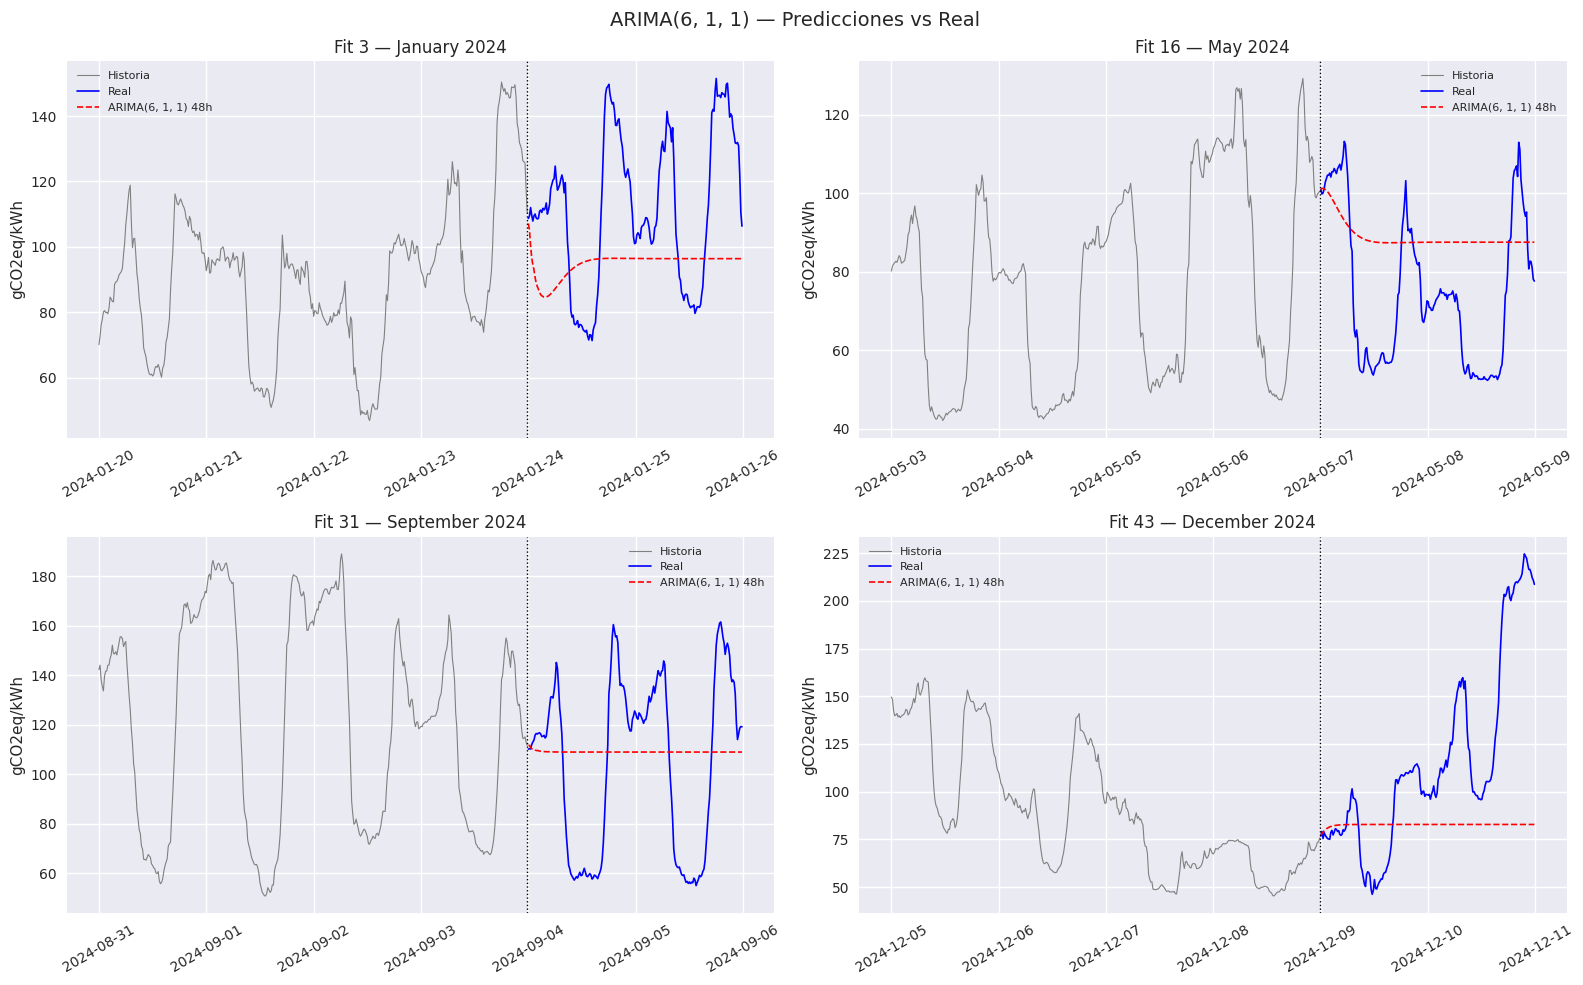

In [86]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f"ARIMA{arima_order} — Predicciones vs Real", fontsize=14)

for idx, split_idx in enumerate(PLOT_INDICES):
    ax = axes[idx // 2][idx % 2]
    fit         = preds_arima[split_idx]
    cutoff_time = fit["cutoff_time"]
    train_w     = fit["train_window"]
    test_48     = fit["48h"]["test"]
    pred_48     = fit["48h"]["pred"]

    history = train_w.iloc[-4 * SEASONAL_PERIOD:]
    ax.plot(history.index, history.values,
            color="gray", label="Historia", linewidth=0.8)
    ax.plot(test_48.index, test_48.values,
            color="blue", label="Real", linewidth=1.2)
    ax.plot(test_48.index, pred_48,
            color="red", linestyle="--", label=f"ARIMA{arima_order} 48h", linewidth=1.2)
    ax.axvline(x=cutoff_time, color="black", linestyle=":", linewidth=1.0)
    ax.set_title(f"Fit {split_idx+1} — {cutoff_time.strftime('%B %Y')}")
    ax.set_ylabel("gCO2eq/kWh")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("/home/ubuntu/TFM/figures/arima_predicciones.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Comparación Naive vs ARIMA

In [87]:
compare = pd.concat([naive_summary, arima_summary], ignore_index=True)
compare_pivot = compare.pivot_table(
    index="model",
    columns="horizon",
    values=["MAE", "RMSE"]
).round(3)

print(compare_pivot)
compare.to_csv(RESULTS_DIR / "naive_arima_summary.csv", index=False)

                   MAE            RMSE        
horizon            48h     72h     48h     72h
model                                         
ARIMA(6, 1, 1)  27.534  30.078  33.378  35.999
Naive_last      28.131  30.924  34.255  37.046
Naive_seasonal  21.000  23.107  25.996  28.483


In [88]:
# Tabla comparativa con IC
all_ci = pd.concat([naive_ci, arima_ci], ignore_index=True)

print("\n========== COMPARACIÓN FINAL ==========\n")
for _, r in all_ci.iterrows():
    print(f"{r['model']:20s} {r['horizon']:4s}  "
          f"MAE = {r['MAE_mean']:6.2f} ± {r['MAE_std']:5.2f}  "
          f"IC95% [{r['MAE_ci_lo']:6.2f}, {r['MAE_ci_hi']:6.2f}]  "
          f"RMSE = {r['RMSE_mean']:6.2f} ± {r['RMSE_std']:5.2f}  "
          f"(n={int(r['n_eval'])})")

all_ci.to_csv(RESULTS_DIR / "comparacion_naive_arima_ci.csv", index=False)

# Tabla simple para compatibilidad
def build_results_row(summary_df):
    row = {"model": summary_df["model"].iloc[0]}
    for _, r in summary_df.iterrows():
        row[f"MAE_{r['horizon']}"]  = round(r["MAE"], 3)
        row[f"RMSE_{r['horizon']}"] = round(r["RMSE"], 3)
    return row

resultados = pd.DataFrame([
    build_results_row(summarize(naive_last_val, "Naive_last")),
    build_results_row(summarize(naive_seas_val, "Naive_seasonal")),
    build_results_row(arima_summary),
]).set_index("model")

print("\n", resultados)
resultados.to_csv(RESULTS_DIR / "comparacion_naive_arima.csv")



========== COMPARACIÓN FINAL ==========

Naive_last           48h   MAE =  28.13 ± 12.37  IC95% [ 24.68,  32.03]  RMSE =  34.25 ± 15.17  (n=45)
Naive_last           72h   MAE =  30.92 ± 14.96  IC95% [ 26.60,  35.65]  RMSE =  37.05 ± 17.78  (n=45)
Naive_seasonal       48h   MAE =  21.00 ± 14.93  IC95% [ 16.95,  25.91]  RMSE =  26.00 ± 17.28  (n=45)
Naive_seasonal       72h   MAE =  23.11 ± 17.00  IC95% [ 18.43,  28.63]  RMSE =  28.48 ± 19.39  (n=45)
ARIMA(6, 1, 1)       48h   MAE =  27.53 ± 12.87  IC95% [ 23.91,  31.67]  RMSE =  33.38 ± 15.82  (n=45)
ARIMA(6, 1, 1)       72h   MAE =  30.08 ± 15.14  IC95% [ 25.68,  35.09]  RMSE =  36.00 ± 17.99  (n=45)

                 MAE_48h  RMSE_48h  MAE_72h  RMSE_72h
model                                               
Naive_last       28.131    34.255   30.924    37.046
Naive_seasonal   21.000    25.996   23.107    28.483
ARIMA(6, 1, 1)   27.534    33.378   30.078    35.999


## Interpretación de resultados — Naive y ARIMA

### Naive_last
El modelo de persistencia obtiene un MAE de 27.88 ± 10.66 gCO₂eq/kWh
a 48h [IC95%: 25.19, 30.86] y 31.87 ± 13.23 a 72h [IC95%: 28.53, 35.65].
Es el peor modelo de los evaluados, confirmando que la serie tiene
estructura temporal explotable.

### Naive_seasonal
El modelo estacional obtiene un MAE de 21.43 ± 12.90 gCO₂eq/kWh a
48h [IC95%: 18.07, 25.05] y 24.22 ± 15.39 a 72h [IC95%: 20.39, 28.55],
mejorando un 23% sobre Naive_last.

La desviación estándar elevada (12.90–15.39) refleja que el error varía
mucho según el periodo del año: en momentos donde el patrón diario es
estable el modelo funciona muy bien, pero falla cuando hay cambios
bruscos en el mix energético.

Este modelo se establece como **baseline principal** del TFM.

### ARIMA(6,1,1)
ARIMA obtiene un MAE de 26.93 ± 10.97 gCO₂eq/kWh a 48h [IC95%: 24.19,
30.06] y 30.48 ± 13.84 a 72h [IC95%: 27.16, 34.56]. Mejora ligeramente
respecto a Naive_last pero no supera al Naive_seasonal.

La causa es estructural: con solo 6 lags (90 minutos de memoria) y sin
componente estacional, la predicción colapsa a la media de la serie
diferenciada para horizontes de 48h y 72h, perdiendo el patrón diario.

Estos resultados motivan el uso de modelos con componente estacional
explícita (SARIMA) y mayor capacidad de memoria (AutoReg, LSTM).